# COMP90055 Project

## Experiment Graphs

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt

## 1. System Performance

In [8]:
with open("../experiments/ver1_expRes.json", "r") as f:
     sys_results = json.load(f)

In [10]:
len(sys_results)

180

Success Rate: 79.44%
Average Runtime (sec): 25.44
Average Top-5 Recall: 0.50
Average Distance Deviation (m): 2364.05
Error Rate: 20.56%


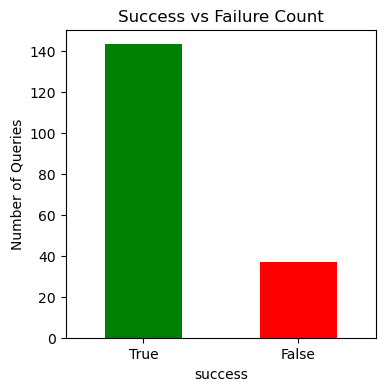

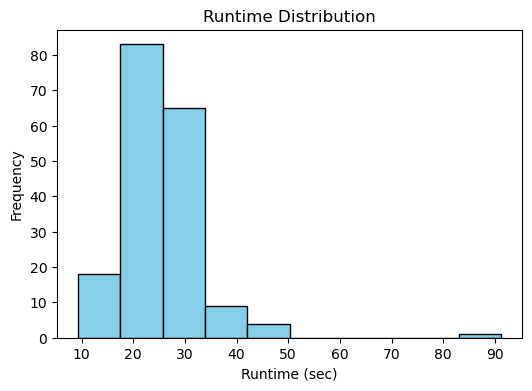

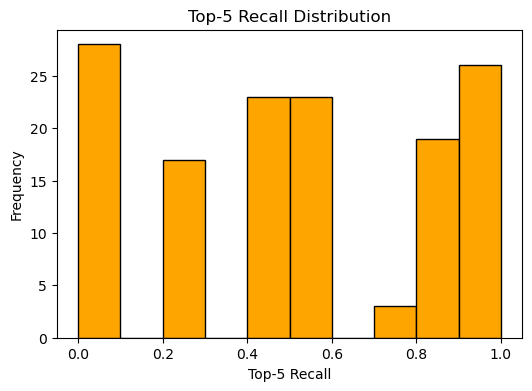

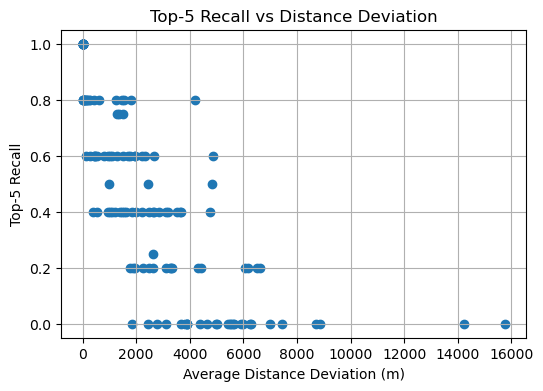

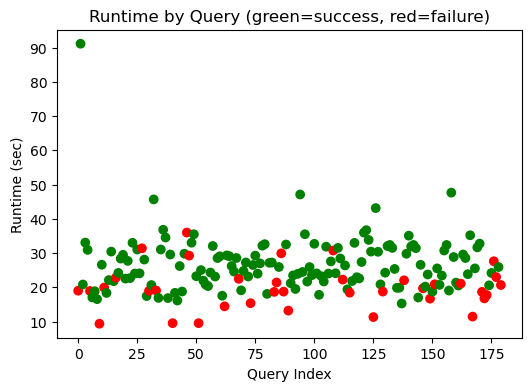

In [11]:
# Convert to DataFrame
df = pd.DataFrame(sys_results)

# ---- Compute summary metrics ----
success_rate = df['success'].mean()  # proportion of True
avg_runtime = df['runtime_sec'].mean()

# Handle possible None/NaN
avg_top5_recall = df['top5_recall'].dropna().mean()
avg_dist_dev = df['avg_dist_dev_m'].dropna().mean()

print(f"Success Rate: {success_rate:.2%}")
print(f"Average Runtime (sec): {avg_runtime:.2f}")
print(f"Average Top-5 Recall: {avg_top5_recall:.2f}")
print(f"Average Distance Deviation (m): {avg_dist_dev:.2f}")

# You can also compute other metrics:
# e.g. error rate
error_rate = df['error'].notna().mean()
print(f"Error Rate: {error_rate:.2%}")

# ---- Draw some graphs ----

# 1. Success vs Fail Count
plt.figure(figsize=(4,4))
df['success'].value_counts().plot(kind='bar', color=['green','red'])
plt.title('Success vs Failure Count')
plt.ylabel('Number of Queries')
plt.xticks(rotation=0)
plt.show()

# 2. Runtime distribution
plt.figure(figsize=(6,4))
df['runtime_sec'].plot(kind='hist', bins=10, color='skyblue', edgecolor='black')
plt.title('Runtime Distribution')
plt.xlabel('Runtime (sec)')
plt.ylabel('Frequency')
plt.show()

# 3. Top-5 Recall distribution
plt.figure(figsize=(6,4))
df['top5_recall'].dropna().plot(kind='hist', bins=10, color='orange', edgecolor='black')
plt.title('Top-5 Recall Distribution')
plt.xlabel('Top-5 Recall')
plt.ylabel('Frequency')
plt.show()

# 4. Scatter plot: Distance deviation vs Top5 recall
if df['avg_dist_dev_m'].notna().any() and df['top5_recall'].notna().any():
    plt.figure(figsize=(6,4))
    plt.scatter(df['avg_dist_dev_m'], df['top5_recall'])
    plt.title('Top-5 Recall vs Distance Deviation')
    plt.xlabel('Average Distance Deviation (m)')
    plt.ylabel('Top-5 Recall')
    plt.grid(True)
    plt.show()

# 5. Optional: runtime vs success scatter
plt.figure(figsize=(6,4))
colors = df['success'].map({True:'green', False:'red'})
plt.scatter(df.index, df['runtime_sec'], c=colors)
plt.title('Runtime by Query (green=success, red=failure)')
plt.xlabel('Query Index')
plt.ylabel('Runtime (sec)')
plt.show()


## 2. Baseline Performance

In [12]:
with open("../experiments/zeroShot_baseline_expRes.json", "r") as f:
     baseline_results = json.load(f)

In [ ]:
# Convert to DataFrame
df = pd.DataFrame(baseline_results)

# ---- Compute summary metrics ----
success_rate = df['success'].mean()  # proportion of True
avg_runtime = df['runtime_sec'].mean()

# Handle possible None/NaN
avg_top5_recall = df['top5_recall'].dropna().mean()
avg_dist_dev = df['avg_dist_dev_m'].dropna().mean()

print(f"Success Rate: {success_rate:.2%}")
print(f"Average Runtime (sec): {avg_runtime:.2f}")
print(f"Average Top-5 Recall: {avg_top5_recall:.2f}")
print(f"Average Distance Deviation (m): {avg_dist_dev:.2f}")

# You can also compute other metrics:
# e.g. error rate
error_rate = df['error'].notna().mean()
print(f"Error Rate: {error_rate:.2%}")

# ---- Draw some graphs ----

# 1. Success vs Fail Count
plt.figure(figsize=(4,4))
df['success'].value_counts().plot(kind='bar', color=['green','red'])
plt.title('Success vs Failure Count')
plt.ylabel('Number of Queries')
plt.xticks(rotation=0)
plt.show()

# 2. Runtime distribution
plt.figure(figsize=(6,4))
df['runtime_sec'].plot(kind='hist', bins=10, color='skyblue', edgecolor='black')
plt.title('Runtime Distribution')
plt.xlabel('Runtime (sec)')
plt.ylabel('Frequency')
plt.show()

# 3. Top-5 Recall distribution
plt.figure(figsize=(6,4))
df['top5_recall'].dropna().plot(kind='hist', bins=10, color='orange', edgecolor='black')
plt.title('Top-5 Recall Distribution')
plt.xlabel('Top-5 Recall')
plt.ylabel('Frequency')
plt.show()

# 4. Scatter plot: Distance deviation vs Top5 recall
if df['avg_dist_dev_m'].notna().any() and df['top5_recall'].notna().any():
    plt.figure(figsize=(6,4))
    plt.scatter(df['avg_dist_dev_m'], df['top5_recall'])
    plt.title('Top-5 Recall vs Distance Deviation')
    plt.xlabel('Average Distance Deviation (m)')
    plt.ylabel('Top-5 Recall')
    plt.grid(True)
    plt.show()

# 5. Optional: runtime vs success scatter
plt.figure(figsize=(6,4))
colors = df['success'].map({True:'green', False:'red'})
plt.scatter(df.index, df['runtime_sec'], c=colors)
plt.title('Runtime by Query (green=success, red=failure)')
plt.xlabel('Query Index')
plt.ylabel('Runtime (sec)')
plt.show()


## Case Study

In [37]:
import folium
import polyline  # to decode Google encoded polyline strings

# 1️⃣ your polyline(s)
polylines = ['z_}eFwhytZN}B\\B?YJyA]ELiCAU_Hu@{OaBmNsAePeBm^eEeGy@g@C}Em@{Bc@uA_@sEw@iGu@Q?iBY}{@yIkRqBsRkBa@FmCDMJ[LQRQZU~@oB|VSR}@jQyAxTM`DGhFBfEP~Dd@vJDjDC~DSzDY|Ce@~Cu@nDuC|Ku@|Do@lEe@tEQpCi@lFUlBm@|Di@|Bm@rBaAjCcAzBmBjDeDfFaArAeUvXqBzBqBhBkBnAwDlBmAb@uCv@uFhA{Bl@_Bp@kAl@eA|@_A`AoAdBcArB]|@c@tAg@dCWbCKbCCbABnD^hNJjJDpKC`JObM?~CRtGLhB`@rCnCbMh@pBt@pB~GbQ|A|Eh@tB`BjIn@pE\\xDZtEVhIFbDRnEZpD`@tCr@hDt@jCdApCxAxCvBvD|BpDhAfBhDnF~BlEpApCtAdEj@|Bl@pDVxBPfCHjEEhEQhEk@vKUvHM|LBfPFvINhIN~D|A`Y^jKNhK?jFK`Ha@lLMbLCfFLhGV|Dl@bGd@~Cd@lCjCpLfHnX|AnHpAtG~@~F`@|DZ~DHlBBrDCbEOpFUdFy@zMY`Ca@~Ak@jBUbAOvAC\\AfAoAjVKtCGTyBrb@wAl[{Bbc@?dALb@F\\oOuA{BYo]aDeAGsGo@yCSwLgA{Gm@a@UqHi@aDMsVyB{f@cF']

# 2️⃣ ground truth POIs
ground_truth = [
    {"name": "Genesis Health and Fitness", "lat": -37.831555699999996, "lon": 145.13594179999998},
    {"name": "Snap Fitness 24/7 Brunswick", "lat": -37.7765771, "lon": 144.9608201},
    {"name": "Elite Training & Sports Medicine Bulleen", "lat": -37.772375499999995, "lon": 145.07773090000003},
    {"name": "Healthy Fit", "lat": -37.7845258, "lon": 144.9824659},
    {"name": "Fitness First Doncaster", "lat": -37.787065, "lon": 145.12627469999998}
]

# 3️⃣ system output POIs
# system_outputs = [
#     {"name": "FoodWorks", "lat": -37.8031707, "lon": 144.9490491},
#     {"name": "Woolworths Sunshine Market Place", "lat": -37.7804866, "lon": 144.8319839},
#     {"name": "atmx Royal Childrens Hospital", "lat": -37.793845999999995, "lon": 144.9488544},
#     {"name": "KFL Supermarket Braybrook", "lat": -37.7824939, "lon": 144.8642719},
#     {"name": "Friendly Grocer & Bottlemart", "lat": -37.7911383, "lon": 144.889998}
# ]

# 4️⃣ create the map centered on first polyline start
first_polyline_coords = polyline.decode(polylines[0])
m = folium.Map(location=first_polyline_coords[0], zoom_start=11)

# draw all polylines
for pl in polylines:
    coords = polyline.decode(pl)
    folium.PolyLine(coords, color="blue", weight=4, opacity=0.7).add_to(m)

# ground truth markers (green)
for g in ground_truth:
    folium.Marker(
        location=[g["lat"], g["lon"]],
        popup=g["name"],
        icon=folium.Icon(color="green", icon="ok-sign"),
    ).add_to(m)

# system output markers (red)
# for s in system_outputs:
#     folium.Marker(
#         location=[s["lat"], s["lon"]],
#         popup=s["name"],
#         icon=folium.Icon(color="red", icon="info-sign"),
#     ).add_to(m)

# save
m.save("map_demo.html")
print("Map saved to map_demo.html")

Map saved to map_demo.html


# Group the Results

## 1. System

In [19]:
with open("../experiments/ver1_expRes.json", "r") as f:
     sys_results = json.load(f)

In [20]:
# group the results

for res in sys_results:
    
    # Type 1 ques
    if 'passing' in res["user_input"]:
        res["ques_type"] = 2
    elif 'within' in res["user_input"]:
        res["ques_type"] = 3
    else:
        res["ques_type"] = 1
        
type1_res = [res for res in sys_results if res["ques_type"]==1]
type2_res = [res for res in sys_results if res["ques_type"]==2]
type3_res = [res for res in sys_results if res["ques_type"]==3]

Success Rate: 85.00%
Average Runtime (sec): 19.96
Average Top-5 Recall: 0.64
Average Distance Deviation (m): 1449.49
Error Rate: 15.00%


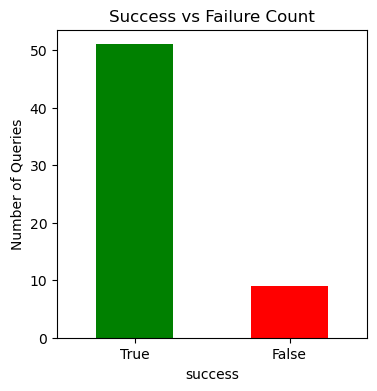

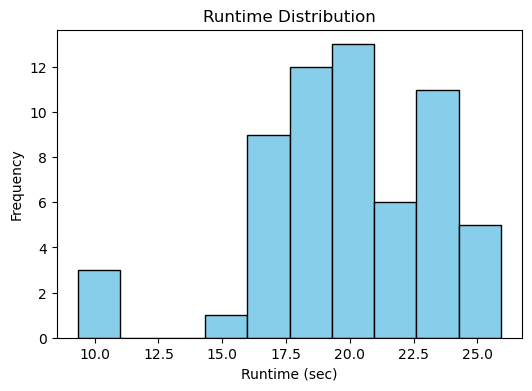

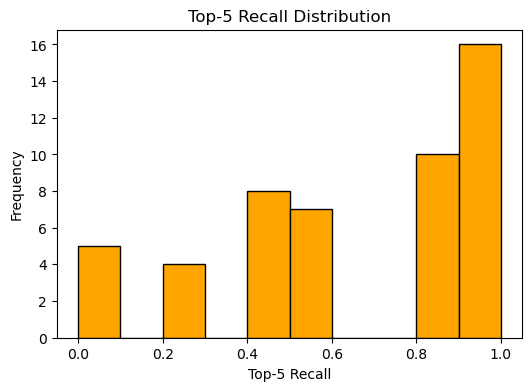

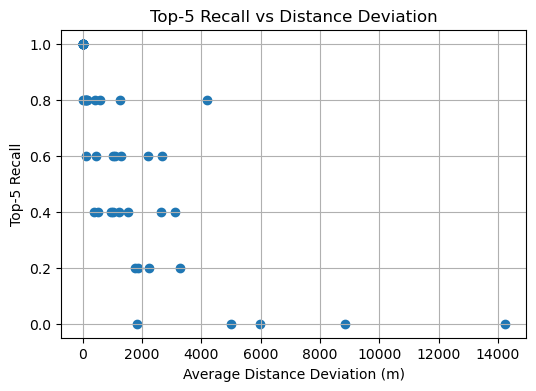

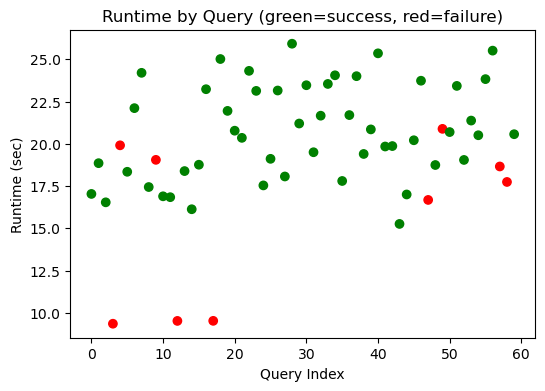

In [24]:
# Convert to DataFrame
df = pd.DataFrame(type1_res)

# ---- Compute summary metrics ----
success_rate = df['success'].mean()  # proportion of True
avg_runtime = df['runtime_sec'].mean()

# Handle possible None/NaN
avg_top5_recall = df['top5_recall'].dropna().mean()
avg_dist_dev = df['avg_dist_dev_m'].dropna().mean()

print(f"Success Rate: {success_rate:.2%}")
print(f"Average Runtime (sec): {avg_runtime:.2f}")
print(f"Average Top-5 Recall: {avg_top5_recall:.2f}")
print(f"Average Distance Deviation (m): {avg_dist_dev:.2f}")

# You can also compute other metrics:
# e.g. error rate
error_rate = df['error'].notna().mean()
print(f"Error Rate: {error_rate:.2%}")

# ---- Draw some graphs ----

# 1. Success vs Fail Count
plt.figure(figsize=(4,4))
df['success'].value_counts().plot(kind='bar', color=['green','red'])
plt.title('Success vs Failure Count')
plt.ylabel('Number of Queries')
plt.xticks(rotation=0)
plt.show()

# 2. Runtime distribution
plt.figure(figsize=(6,4))
df['runtime_sec'].plot(kind='hist', bins=10, color='skyblue', edgecolor='black')
plt.title('Runtime Distribution')
plt.xlabel('Runtime (sec)')
plt.ylabel('Frequency')
plt.show()

# 3. Top-5 Recall distribution
plt.figure(figsize=(6,4))
df['top5_recall'].dropna().plot(kind='hist', bins=10, color='orange', edgecolor='black')
plt.title('Top-5 Recall Distribution')
plt.xlabel('Top-5 Recall')
plt.ylabel('Frequency')
plt.show()

# 4. Scatter plot: Distance deviation vs Top5 recall
if df['avg_dist_dev_m'].notna().any() and df['top5_recall'].notna().any():
    plt.figure(figsize=(6,4))
    plt.scatter(df['avg_dist_dev_m'], df['top5_recall'])
    plt.title('Top-5 Recall vs Distance Deviation')
    plt.xlabel('Average Distance Deviation (m)')
    plt.ylabel('Top-5 Recall')
    plt.grid(True)
    plt.show()

# 5. Optional: runtime vs success scatter
plt.figure(figsize=(6,4))
colors = df['success'].map({True:'green', False:'red'})
plt.scatter(df.index, df['runtime_sec'], c=colors)
plt.title('Runtime by Query (green=success, red=failure)')
plt.xlabel('Query Index')
plt.ylabel('Runtime (sec)')
plt.show()

Success Rate: 78.33%
Average Runtime (sec): 28.23
Average Top-5 Recall: 0.55
Average Distance Deviation (m): 2425.07
Error Rate: 21.67%


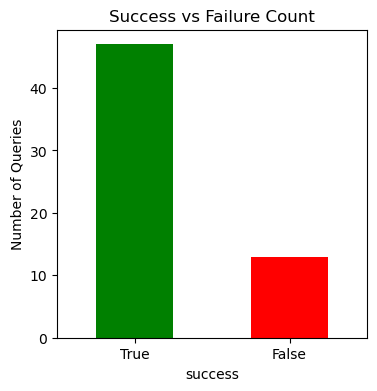

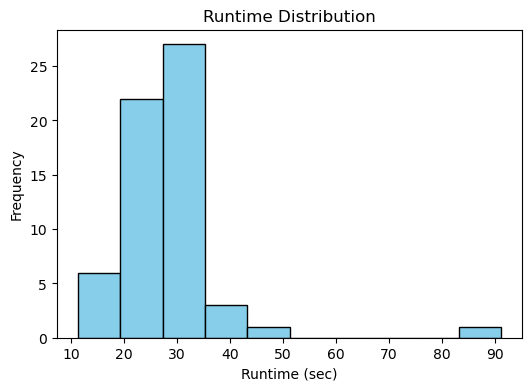

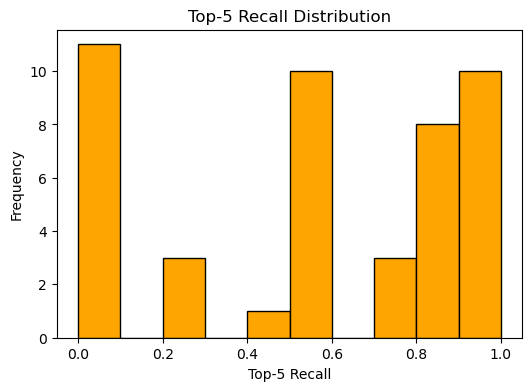

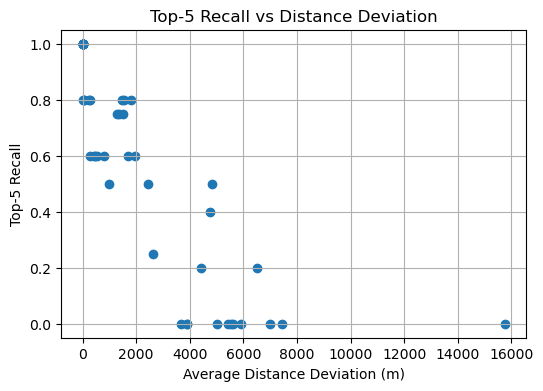

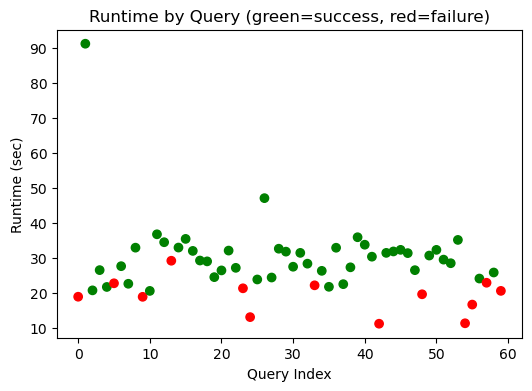

In [26]:
# Convert to DataFrame
df = pd.DataFrame(type2_res)

# ---- Compute summary metrics ----
success_rate = df['success'].mean()  # proportion of True
avg_runtime = df['runtime_sec'].mean()

# Handle possible None/NaN
avg_top5_recall = df['top5_recall'].dropna().mean()
avg_dist_dev = df['avg_dist_dev_m'].dropna().mean()

print(f"Success Rate: {success_rate:.2%}")
print(f"Average Runtime (sec): {avg_runtime:.2f}")
print(f"Average Top-5 Recall: {avg_top5_recall:.2f}")
print(f"Average Distance Deviation (m): {avg_dist_dev:.2f}")

# You can also compute other metrics:
# e.g. error rate
error_rate = df['error'].notna().mean()
print(f"Error Rate: {error_rate:.2%}")

# ---- Draw some graphs ----

# 1. Success vs Fail Count
plt.figure(figsize=(4,4))
df['success'].value_counts().plot(kind='bar', color=['green','red'])
plt.title('Success vs Failure Count')
plt.ylabel('Number of Queries')
plt.xticks(rotation=0)
plt.show()

# 2. Runtime distribution
plt.figure(figsize=(6,4))
df['runtime_sec'].plot(kind='hist', bins=10, color='skyblue', edgecolor='black')
plt.title('Runtime Distribution')
plt.xlabel('Runtime (sec)')
plt.ylabel('Frequency')
plt.show()

# 3. Top-5 Recall distribution
plt.figure(figsize=(6,4))
df['top5_recall'].dropna().plot(kind='hist', bins=10, color='orange', edgecolor='black')
plt.title('Top-5 Recall Distribution')
plt.xlabel('Top-5 Recall')
plt.ylabel('Frequency')
plt.show()

# 4. Scatter plot: Distance deviation vs Top5 recall
if df['avg_dist_dev_m'].notna().any() and df['top5_recall'].notna().any():
    plt.figure(figsize=(6,4))
    plt.scatter(df['avg_dist_dev_m'], df['top5_recall'])
    plt.title('Top-5 Recall vs Distance Deviation')
    plt.xlabel('Average Distance Deviation (m)')
    plt.ylabel('Top-5 Recall')
    plt.grid(True)
    plt.show()

# 5. Optional: runtime vs success scatter
plt.figure(figsize=(6,4))
colors = df['success'].map({True:'green', False:'red'})
plt.scatter(df.index, df['runtime_sec'], c=colors)
plt.title('Runtime by Query (green=success, red=failure)')
plt.xlabel('Query Index')
plt.ylabel('Runtime (sec)')
plt.show()

Success Rate: 75.00%
Average Runtime (sec): 28.12
Average Top-5 Recall: 0.28
Average Distance Deviation (m): 3362.21
Error Rate: 25.00%


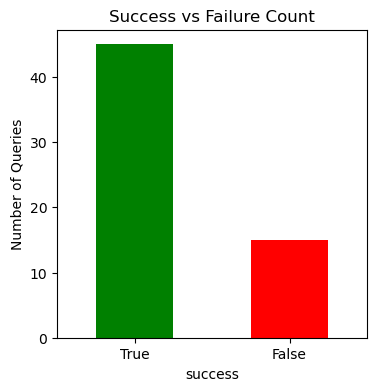

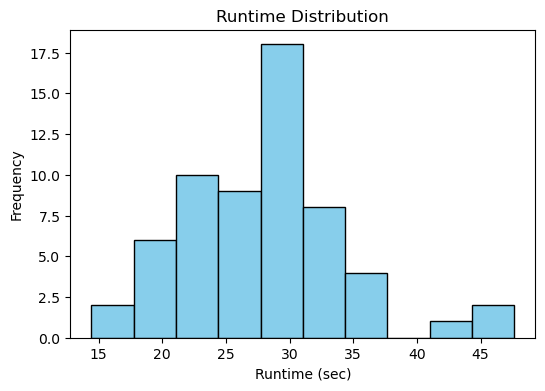

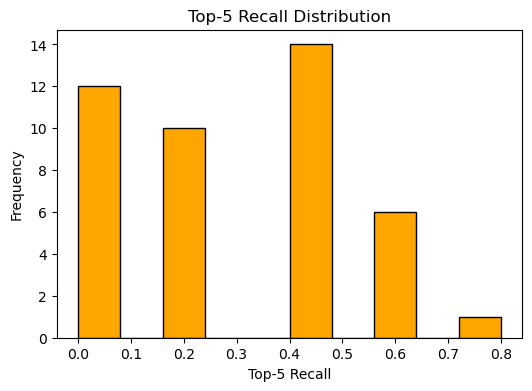

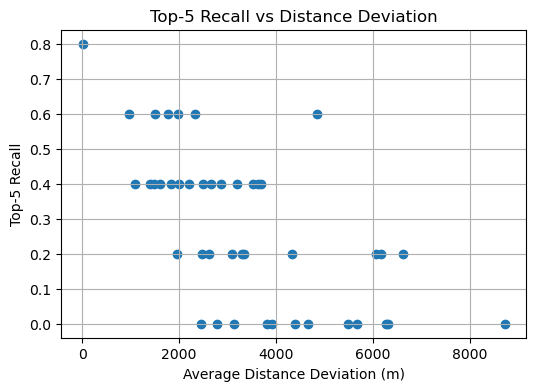

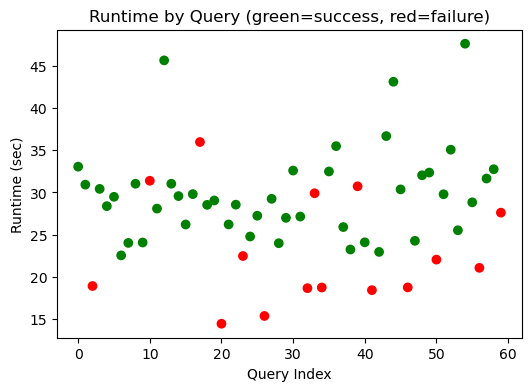

In [27]:
# Convert to DataFrame
df = pd.DataFrame(type3_res)

# ---- Compute summary metrics ----
success_rate = df['success'].mean()  # proportion of True
avg_runtime = df['runtime_sec'].mean()

# Handle possible None/NaN
avg_top5_recall = df['top5_recall'].dropna().mean()
avg_dist_dev = df['avg_dist_dev_m'].dropna().mean()

print(f"Success Rate: {success_rate:.2%}")
print(f"Average Runtime (sec): {avg_runtime:.2f}")
print(f"Average Top-5 Recall: {avg_top5_recall:.2f}")
print(f"Average Distance Deviation (m): {avg_dist_dev:.2f}")

# You can also compute other metrics:
# e.g. error rate
error_rate = df['error'].notna().mean()
print(f"Error Rate: {error_rate:.2%}")

# ---- Draw some graphs ----

# 1. Success vs Fail Count
plt.figure(figsize=(4,4))
df['success'].value_counts().plot(kind='bar', color=['green','red'])
plt.title('Success vs Failure Count')
plt.ylabel('Number of Queries')
plt.xticks(rotation=0)
plt.show()

# 2. Runtime distribution
plt.figure(figsize=(6,4))
df['runtime_sec'].plot(kind='hist', bins=10, color='skyblue', edgecolor='black')
plt.title('Runtime Distribution')
plt.xlabel('Runtime (sec)')
plt.ylabel('Frequency')
plt.show()

# 3. Top-5 Recall distribution
plt.figure(figsize=(6,4))
df['top5_recall'].dropna().plot(kind='hist', bins=10, color='orange', edgecolor='black')
plt.title('Top-5 Recall Distribution')
plt.xlabel('Top-5 Recall')
plt.ylabel('Frequency')
plt.show()

# 4. Scatter plot: Distance deviation vs Top5 recall
if df['avg_dist_dev_m'].notna().any() and df['top5_recall'].notna().any():
    plt.figure(figsize=(6,4))
    plt.scatter(df['avg_dist_dev_m'], df['top5_recall'])
    plt.title('Top-5 Recall vs Distance Deviation')
    plt.xlabel('Average Distance Deviation (m)')
    plt.ylabel('Top-5 Recall')
    plt.grid(True)
    plt.show()

# 5. Optional: runtime vs success scatter
plt.figure(figsize=(6,4))
colors = df['success'].map({True:'green', False:'red'})
plt.scatter(df.index, df['runtime_sec'], c=colors)
plt.title('Runtime by Query (green=success, red=failure)')
plt.xlabel('Query Index')
plt.ylabel('Runtime (sec)')
plt.show()

## 2. Baseline

In [28]:
with open("../experiments/zeroShot_baseline_expRes.json", "r") as f:
     baseline_results = json.load(f)

In [29]:
# group the results

for res in baseline_results:
    
    # Type 1 ques
    if 'passing' in res["user_input"]:
        res["ques_type"] = 2
    elif 'within' in res["user_input"]:
        res["ques_type"] = 3
    else:
        res["ques_type"] = 1
        
type1_baseline_res = [res for res in baseline_results if res["ques_type"]==1]
type2_baseline_res = [res for res in baseline_results if res["ques_type"]==2]
type3_baseline_res = [res for res in baseline_results if res["ques_type"]==3]

Success Rate: 96.67%
Average Runtime (sec): 8.14
Average Top-5 Recall: 0.00
Average Distance Deviation (m): 1842827.79
Error Rate: 3.33%


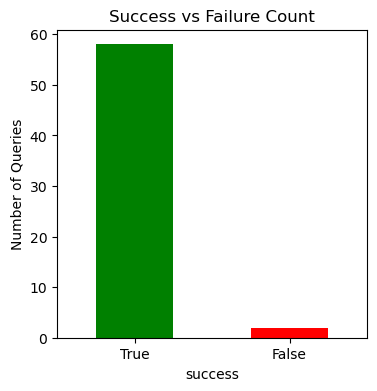

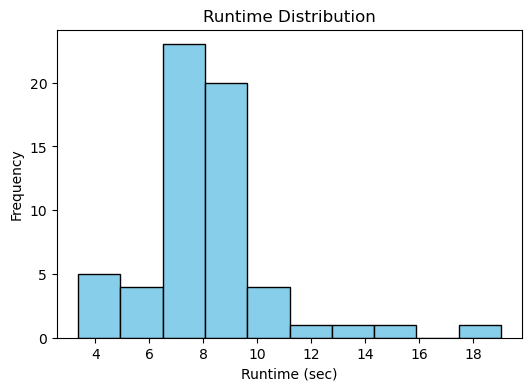

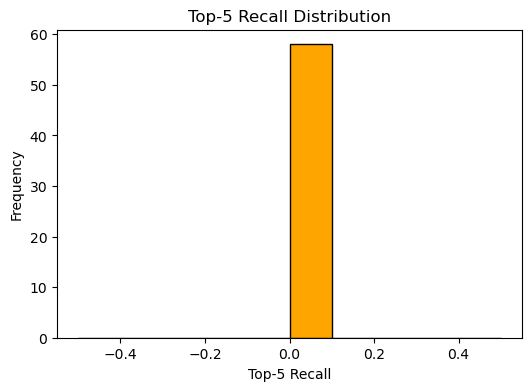

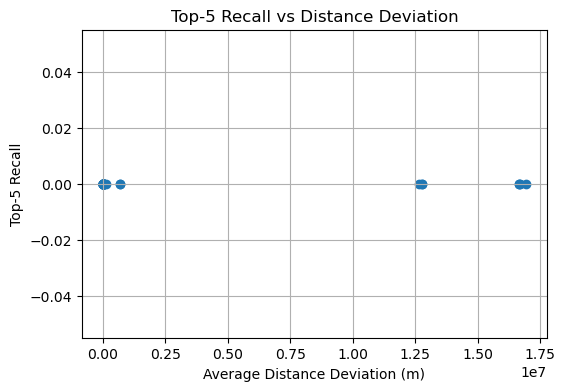

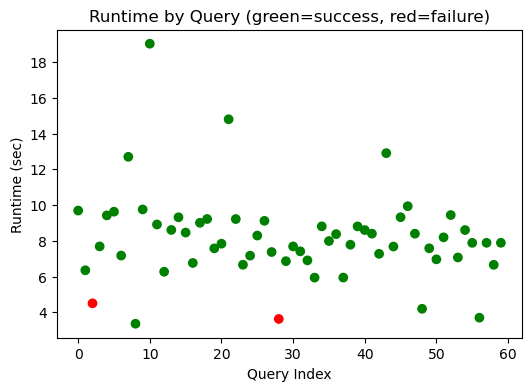

In [30]:
# Convert to DataFrame
df_baseline = pd.DataFrame(type1_baseline_res)

# ---- Compute summary metrics ----
success_rate = df_baseline['success'].mean()  # proportion of True
avg_runtime = df_baseline['runtime_sec'].mean()

# Handle possible None/NaN
avg_top5_recall = df_baseline['top5_recall'].dropna().mean()
avg_dist_dev = df_baseline['avg_dist_dev_m'].dropna().mean()

print(f"Success Rate: {success_rate:.2%}")
print(f"Average Runtime (sec): {avg_runtime:.2f}")
print(f"Average Top-5 Recall: {avg_top5_recall:.2f}")
print(f"Average Distance Deviation (m): {avg_dist_dev:.2f}")

# You can also compute other metrics:
# e.g. error rate
error_rate = df_baseline['error'].notna().mean()
print(f"Error Rate: {error_rate:.2%}")

# ---- Draw some graphs ----

# 1. Success vs Fail Count
plt.figure(figsize=(4,4))
df_baseline['success'].value_counts().plot(kind='bar', color=['green','red'])
plt.title('Success vs Failure Count')
plt.ylabel('Number of Queries')
plt.xticks(rotation=0)
plt.show()

# 2. Runtime distribution
plt.figure(figsize=(6,4))
df_baseline['runtime_sec'].plot(kind='hist', bins=10, color='skyblue', edgecolor='black')
plt.title('Runtime Distribution')
plt.xlabel('Runtime (sec)')
plt.ylabel('Frequency')
plt.show()

# 3. Top-5 Recall distribution
plt.figure(figsize=(6,4))
df_baseline['top5_recall'].dropna().plot(kind='hist', bins=10, color='orange', edgecolor='black')
plt.title('Top-5 Recall Distribution')
plt.xlabel('Top-5 Recall')
plt.ylabel('Frequency')
plt.show()

# 4. Scatter plot: Distance deviation vs Top5 recall
if df_baseline['avg_dist_dev_m'].notna().any() and df_baseline['top5_recall'].notna().any():
    plt.figure(figsize=(6,4))
    plt.scatter(df_baseline['avg_dist_dev_m'], df_baseline['top5_recall'])
    plt.title('Top-5 Recall vs Distance Deviation')
    plt.xlabel('Average Distance Deviation (m)')
    plt.ylabel('Top-5 Recall')
    plt.grid(True)
    plt.show()

# 5. Optional: runtime vs success scatter
plt.figure(figsize=(6,4))
colors = df_baseline['success'].map({True:'green', False:'red'})
plt.scatter(df_baseline.index, df_baseline['runtime_sec'], c=colors)
plt.title('Runtime by Query (green=success, red=failure)')
plt.xlabel('Query Index')
plt.ylabel('Runtime (sec)')
plt.show()

Success Rate: 100.00%
Average Runtime (sec): 8.39
Average Top-5 Recall: 0.00
Average Distance Deviation (m): 524141.17
Error Rate: 0.00%


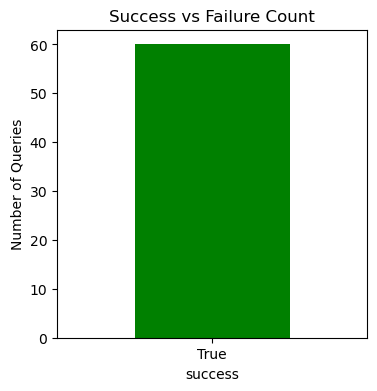

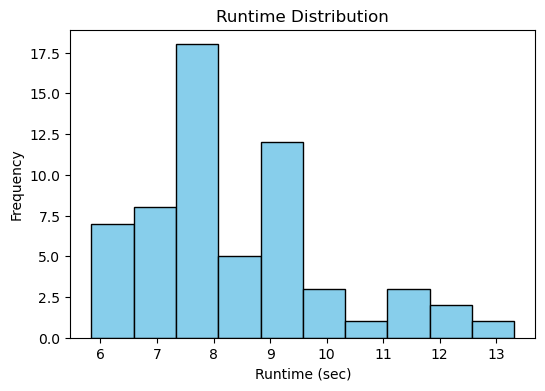

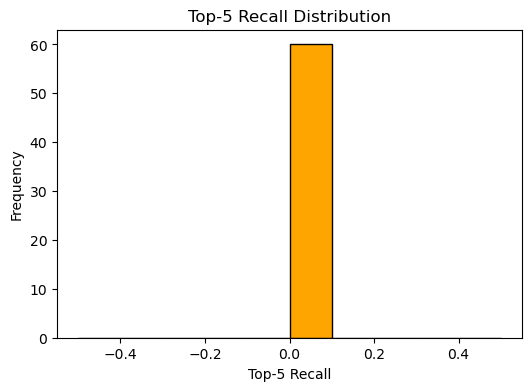

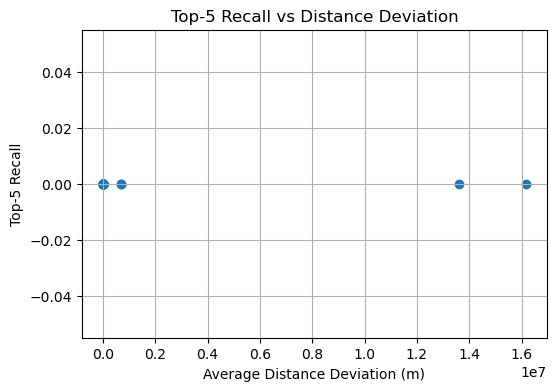

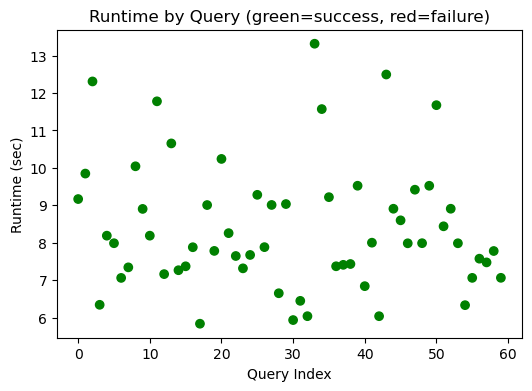

In [31]:
# Convert to DataFrame
df_baseline = pd.DataFrame(type2_baseline_res)

# ---- Compute summary metrics ----
success_rate = df_baseline['success'].mean()  # proportion of True
avg_runtime = df_baseline['runtime_sec'].mean()

# Handle possible None/NaN
avg_top5_recall = df_baseline['top5_recall'].dropna().mean()
avg_dist_dev = df_baseline['avg_dist_dev_m'].dropna().mean()

print(f"Success Rate: {success_rate:.2%}")
print(f"Average Runtime (sec): {avg_runtime:.2f}")
print(f"Average Top-5 Recall: {avg_top5_recall:.2f}")
print(f"Average Distance Deviation (m): {avg_dist_dev:.2f}")

# You can also compute other metrics:
# e.g. error rate
error_rate = df_baseline['error'].notna().mean()
print(f"Error Rate: {error_rate:.2%}")

# ---- Draw some graphs ----

# 1. Success vs Fail Count
plt.figure(figsize=(4,4))
df_baseline['success'].value_counts().plot(kind='bar', color=['green','red'])
plt.title('Success vs Failure Count')
plt.ylabel('Number of Queries')
plt.xticks(rotation=0)
plt.show()

# 2. Runtime distribution
plt.figure(figsize=(6,4))
df_baseline['runtime_sec'].plot(kind='hist', bins=10, color='skyblue', edgecolor='black')
plt.title('Runtime Distribution')
plt.xlabel('Runtime (sec)')
plt.ylabel('Frequency')
plt.show()

# 3. Top-5 Recall distribution
plt.figure(figsize=(6,4))
df_baseline['top5_recall'].dropna().plot(kind='hist', bins=10, color='orange', edgecolor='black')
plt.title('Top-5 Recall Distribution')
plt.xlabel('Top-5 Recall')
plt.ylabel('Frequency')
plt.show()

# 4. Scatter plot: Distance deviation vs Top5 recall
if df_baseline['avg_dist_dev_m'].notna().any() and df_baseline['top5_recall'].notna().any():
    plt.figure(figsize=(6,4))
    plt.scatter(df_baseline['avg_dist_dev_m'], df_baseline['top5_recall'])
    plt.title('Top-5 Recall vs Distance Deviation')
    plt.xlabel('Average Distance Deviation (m)')
    plt.ylabel('Top-5 Recall')
    plt.grid(True)
    plt.show()

# 5. Optional: runtime vs success scatter
plt.figure(figsize=(6,4))
colors = df_baseline['success'].map({True:'green', False:'red'})
plt.scatter(df_baseline.index, df_baseline['runtime_sec'], c=colors)
plt.title('Runtime by Query (green=success, red=failure)')
plt.xlabel('Query Index')
plt.ylabel('Runtime (sec)')
plt.show()

Success Rate: 100.00%
Average Runtime (sec): 8.54
Average Top-5 Recall: 0.00
Average Distance Deviation (m): 958548.66
Error Rate: 0.00%


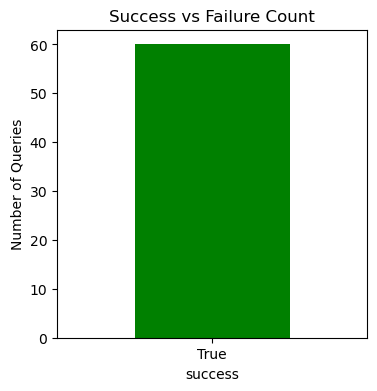

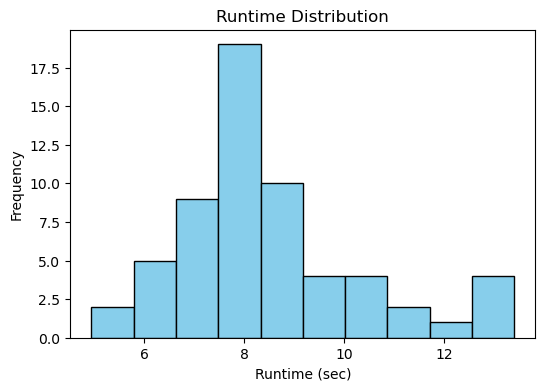

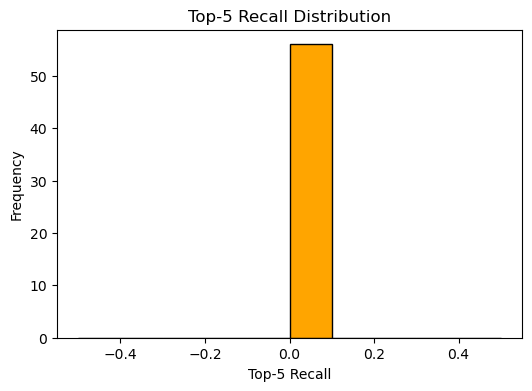

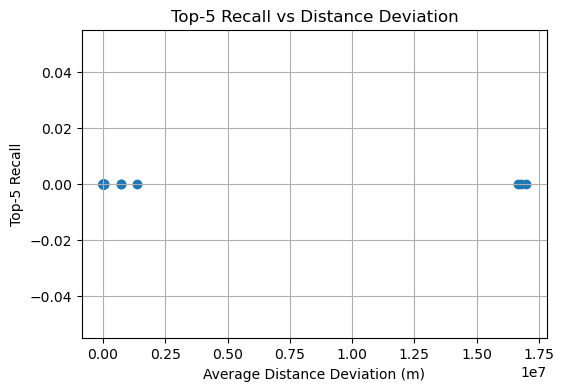

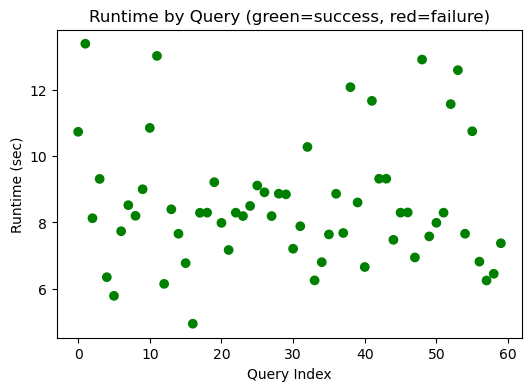

In [32]:
# Convert to DataFrame
df_baseline = pd.DataFrame(type3_baseline_res)

# ---- Compute summary metrics ----
success_rate = df_baseline['success'].mean()  # proportion of True
avg_runtime = df_baseline['runtime_sec'].mean()

# Handle possible None/NaN
avg_top5_recall = df_baseline['top5_recall'].dropna().mean()
avg_dist_dev = df_baseline['avg_dist_dev_m'].dropna().mean()

print(f"Success Rate: {success_rate:.2%}")
print(f"Average Runtime (sec): {avg_runtime:.2f}")
print(f"Average Top-5 Recall: {avg_top5_recall:.2f}")
print(f"Average Distance Deviation (m): {avg_dist_dev:.2f}")

# You can also compute other metrics:
# e.g. error rate
error_rate = df_baseline['error'].notna().mean()
print(f"Error Rate: {error_rate:.2%}")

# ---- Draw some graphs ----

# 1. Success vs Fail Count
plt.figure(figsize=(4,4))
df_baseline['success'].value_counts().plot(kind='bar', color=['green','red'])
plt.title('Success vs Failure Count')
plt.ylabel('Number of Queries')
plt.xticks(rotation=0)
plt.show()

# 2. Runtime distribution
plt.figure(figsize=(6,4))
df_baseline['runtime_sec'].plot(kind='hist', bins=10, color='skyblue', edgecolor='black')
plt.title('Runtime Distribution')
plt.xlabel('Runtime (sec)')
plt.ylabel('Frequency')
plt.show()

# 3. Top-5 Recall distribution
plt.figure(figsize=(6,4))
df_baseline['top5_recall'].dropna().plot(kind='hist', bins=10, color='orange', edgecolor='black')
plt.title('Top-5 Recall Distribution')
plt.xlabel('Top-5 Recall')
plt.ylabel('Frequency')
plt.show()

# 4. Scatter plot: Distance deviation vs Top5 recall
if df_baseline['avg_dist_dev_m'].notna().any() and df_baseline['top5_recall'].notna().any():
    plt.figure(figsize=(6,4))
    plt.scatter(df_baseline['avg_dist_dev_m'], df_baseline['top5_recall'])
    plt.title('Top-5 Recall vs Distance Deviation')
    plt.xlabel('Average Distance Deviation (m)')
    plt.ylabel('Top-5 Recall')
    plt.grid(True)
    plt.show()

# 5. Optional: runtime vs success scatter
plt.figure(figsize=(6,4))
colors = df_baseline['success'].map({True:'green', False:'red'})
plt.scatter(df_baseline.index, df_baseline['runtime_sec'], c=colors)
plt.title('Runtime by Query (green=success, red=failure)')
plt.xlabel('Query Index')
plt.ylabel('Runtime (sec)')
plt.show()